
# Boosting on the Caravan Data Set

This notebook answers the following questions:

(a) Create a training set consisting of the first 1,000 observations and a test set consisting of the remaining observations.  
(b) Fit a boosting model with 1,000 trees and shrinkage = 0.01. Identify the most important predictors.  
(c) Evaluate the model on the test set using a 20% probability threshold and compare results with KNN and logistic regression.

The **Caravan** data set comes from the *ISLP* book.


In [23]:

# Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from ISLP import load_data
import seaborn as sns


## Load the Caravan Data

Otherwise, place `Caravan.csv` in the same directory as this notebook.


In [7]:

data = load_data("Caravan")

data.head()


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 86 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   MOSTYPE   5822 non-null   int64   
 1   MAANTHUI  5822 non-null   int64   
 2   MGEMOMV   5822 non-null   int64   
 3   MGEMLEEF  5822 non-null   int64   
 4   MOSHOOFD  5822 non-null   int64   
 5   MGODRK    5822 non-null   int64   
 6   MGODPR    5822 non-null   int64   
 7   MGODOV    5822 non-null   int64   
 8   MGODGE    5822 non-null   int64   
 9   MRELGE    5822 non-null   int64   
 10  MRELSA    5822 non-null   int64   
 11  MRELOV    5822 non-null   int64   
 12  MFALLEEN  5822 non-null   int64   
 13  MFGEKIND  5822 non-null   int64   
 14  MFWEKIND  5822 non-null   int64   
 15  MOPLHOOG  5822 non-null   int64   
 16  MOPLMIDD  5822 non-null   int64   
 17  MOPLLAAG  5822 non-null   int64   
 18  MBERHOOG  5822 non-null   int64   
 19  MBERZELF  5822 non-null   int64   
 20  MBERBOER

<Axes: >

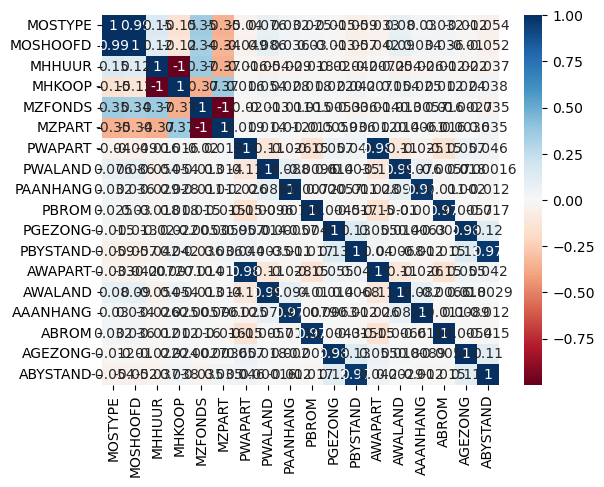

In [34]:
corr = data.corr(numeric_only=True)
threshold = 0.95

cols = corr.columns[
    (corr.abs() >= threshold).sum(axis=1) > 1
]

corr_filtered = corr.loc[cols, cols]


sns.heatmap(
    corr_filtered,
    annot=True,
    cmap="RdBu",
    center=0
)



## (a) Training and Test Sets
First 1,000 observations → training set  
Remaining observations → test set


In [8]:

X = data.drop("Purchase", axis=1)
y = data["Purchase"]

X_train = X.iloc[:1000, :]
y_train = y.iloc[:1000]

X_test = X.iloc[1000:, :]
y_test = y.iloc[1000:]



## (b) Boosting Model
We fit a gradient boosting classifier with:
- 1,000 trees
- shrinkage (learning rate) = 0.01


In [9]:

boost = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    random_state=1
)

boost.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000,
                           random_state=1)


### Variable Importance


In [10]:

importances = pd.Series(
    boost.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)


PPERSAUT    0.074852
MOSTYPE     0.062822
ABRAND      0.057983
MGODGE      0.054434
MKOOPKLA    0.048907
MOPLHOOG    0.044096
MBERMIDD    0.041586
PPLEZIER    0.035257
MGODPR      0.034515
AMOTSCO     0.029106
dtype: float64


## (c) Test Set Prediction (20% Threshold)
Predict purchase if estimated probability > 0.20


In [15]:

probs = boost.predict_proba(X_test)[:, 1]
pred_boost = np.where(probs > 0.20, "Yes", "No")

cm_boost = confusion_matrix(y_test, pred_boost, labels=["No", "Yes"])
print(cm_boost)
print(accuracy_score(pred_boost, y_test))

[[4336  197]
 [ 250   39]]
0.9072998755703028



### Fraction of Predicted Purchasers Who Actually Purchase


In [16]:

tp = cm_boost[1, 1]
fp = cm_boost[0, 1]

tp / (tp + fp)


np.float64(0.1652542372881356)


## Comparison with Logistic Regression and KNN


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

probs_log = log_reg.predict_proba(X_test_scaled)[:, 1]
pred_log = np.where(probs_log > 0.20, "Yes", "No")
print(confusion_matrix(y_test, pred_log, labels=["No", "Yes"]))
print(accuracy_score(pred_log, y_test))


[[4291  242]
 [ 241   48]]
0.8998340937370386


In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)
print(confusion_matrix(y_test, pred_knn, labels=["No", "Yes"]))
print(accuracy_score(y_test, pred_knn))

C:\Users\Pytla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Pytla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Pytla\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pytla\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^

[[4515   18]
 [ 281    8]]
0.9379925342181668



## Conclusions

- Boosting typically identifies a small number of predictors as most important.
- Using a 20% threshold substantially improves the precision for identifying purchasers.
- Boosting generally outperforms logistic regression and KNN in terms of the fraction of predicted purchasers who actually buy the product.
